# Python API for the pycmplot package

---

## Installation

Follow instructions in https://pypi.org/project/pycmplot/

---

## Import the package functions

Four main functions are involved in generated plots

 - `prep_pycmplot_input_info`: formats input streams correctly for data processing function
     - --> auto-detects chrom, pos, snp, pval, and build columns
     - --> auto-detects delimiter
     - --> returns a dictionary with these information that the function below needs to appropriately handle sumstats.
     
 - `get_sumstats_and_merged_sector_list`: processes sumstat for plotting functions (work horse of the package)
     - --> trims variants based on `trim_pval` threshold to increase speed and memory efficiency of plotting functions
     - --> fixes chrom labels
     - --> adds **logP** column if specified
     - --> adds a **LABEL** column which is simply the labels provided by user.
     - --> converts hg19 to hg38 genome build
     - --> identifies lead SNPs based on significance threshold and generates hits table
     - --> generates sector size dictionary for circular plots
     - --> generates dictionary of genome-wide significance and suggestive thresholds per summary stat
     - --> returns a tuple of `merged_sector_sizes`, `sumstats_loaded`, `hits_table`, `signif_lines`, all required by plotting functions
     
 - `plot_linear`: generates linear Manhattan plots
     - --> returns a `fig` object
 - `plot_circular`: generates circular Manhattan plots
     - --> returns a `fig` object 
     
***NB:***
> _Auto-detection of column names and delimiter is very important when dealing with multiple sumstats from different projects or tools with different
> column naming styles._
>
> _The `fig` object returned by `plot_linear` and `plot_circular` can be used in any number of ways including creating multi-panel figures._

In [1]:
from pycmplot import prep_pycmplot_input_info, get_sumstats_and_merged_sector_list, plot_linear, plot_circular

In [4]:
help(prep_pycmplot_input_info)

Help on function prep_pycmplot_input_info in module pycmplot.io:

prep_pycmplot_input_info(sum_stats: 'list[str]', labels: 'list[str]', delim: 'Optional[str]' = None, chrom: 'Optional[str]' = None, pos: 'Optional[str]' = None, snp: 'Optional[str]' = None, pcol: 'Optional[str]' = None, build: 'Optional[str]' = None)
    Resolve column names and delimiter

    Parameters
    ----------
    sum_stats:
        List of file paths to GWAS summary statistics (possibly gzip-compressed).
    labels:
        Track labels in the same order as *sum_stats*.
    delim:
        File delimiter (autodetected if omitted)
    chrom:
        Chromosome column
    pos:
        Position column
    snp:
        SNP or Marker ID column
    pcol:
        P-value column
    build:
        Build version column

    Returns
    -------
    {old_columns, column_dtypes, new_columns, delim}



In [5]:
help(get_sumstats_and_merged_sector_list)

Help on function get_sumstats_and_merged_sector_list in module pycmplot.io:

get_sumstats_and_merged_sector_list(sum_stats: 'list[str]', labels: 'list[str]', logp: 'bool' = False, trim_pval: 'Optional[float]' = None, file_info: 'Optional[dict]' = None, sort_tracks: 'Optional[str]' = 'chrom_len', table_out: 'Optional[str]' = None, signif_threshold: 'Optional[float]' = None, signif_line: 'Optional[float]' = None, suggest_threshold: 'Optional[float]' = None, resources: 'Optional[ResourceConfig]' = None)
    Load summary statistics and compute merged Circos sector sizes.

    Parameters
    ----------
    sum_stats:
        List of file paths to GWAS summary statistics (possibly gzip-compressed).
    labels:
        Track labels in the same order as *sum_stats*.
    file_info:
        Dict keyed by label; each value is a list
        ``[col_names, col_dtypes, rename_map, sep]``.
    sort_tracks:
        ``'label'`` — sort tracks alphabetically by label.
        ``'chrom_len'`` — sort by nu

# Example plotting

### Prepare lists of your summary stats and their corresponding labels

In [2]:
sumstats_list = [
    '/data/awonkam1/kesoh/gwas/sitt/sumher/pycmplot/sitt_all_panels_nHbF_agecut-5_kvik1.step2.assoc.gz', 
    '/data/awonkam1/kesoh/gwas/sitt/sumher/pycmplot/sitt_all_panels_nMCV_agecut-5_kvik1.step2.assoc.gz'
]
labels_list = ['HbF','MCV']

### Pass these lists to the `prep_pycmplot_input_info` function

In [3]:
sumstat_info_dict = prep_pycmplot_input_info(
    sum_stats=sumstats_list,
    labels=labels_list
)

# take a look at the dictionary: the function has auto-detected column names and delimiter
sumstat_info_dict

{'HbF': [['CHR', 'POS', 'SNP', 'P', 'BUILD'],
  {'CHR': str, 'POS': object, 'SNP': str, 'P': float, 'BUILD': str},
  {'CHR': 'CHR', 'POS': 'POS', 'SNP': 'SNP', 'P': 'P', 'BUILD': 'BUILD'},
  '\t'],
 'MCV': [['CHR', 'POS', 'SNP', 'P', 'BUILD'],
  {'CHR': str, 'POS': object, 'SNP': str, 'P': float, 'BUILD': str},
  {'CHR': 'CHR', 'POS': 'POS', 'SNP': 'SNP', 'P': 'P', 'BUILD': 'BUILD'},
  '\t']}

## Important notes
- Hits table will be generated here containing variants and their gene annotations at the set significance threshold using the `signific_threshold` option.
- If say you use a different p-value threshold to highlight positions in the plotting functions, those positions will be highlighted but will not be annotated because annotations in the `hits_table` were generated using a different p-value threshold.
- If you wish to annotate all highlighted positions, then use the same `signif_threshold` and `highlight_threshold` everywhere.

- For instance, below we use the default genome-wide significance threshold by not setting any value

In [7]:
(merged_sector_sizes, sumstats_loaded, hits_table, signif_lines) = get_sumstats_and_merged_sector_list(
    sum_stats=sumstats_list,
    labels=labels_list, 
    file_info=sumstat_info_dict, 
    logp=True, 
    table_out="test_pycmplot_python_api", 
    trim_pval=0.001
)

hits_table

,CHR,POS,SNP,P,BUILD,logP,LABEL,OLD_POS,OLD_BUILD,genic,...,promoter_upstream_flag,gene_density,top_gene,biotype,priority_score,distance,promoter_flag,distance_score,biotype_weight,promoter_bonus
1,2,60493111,2:60493111:SNV,3.039700e-18,hg38,17.517169,HbF,60493111,hg38,True,...,False,46,BCL11A,protein_coding,4.0,0,False,1.0,1.0,0.0
0,16,258003,16:258003:SNV,1.094200e-13,hg38,12.960903,MCV,258003,hg38,True,...,False,150,FAM234A,protein_coding,4.0,0,False,1.0,1.0,0.0


## Generating a linear plot

- We use the results of the function above.
- We will use the **top_gene** column of the hits table for annotation

### No highlighting of significant loci

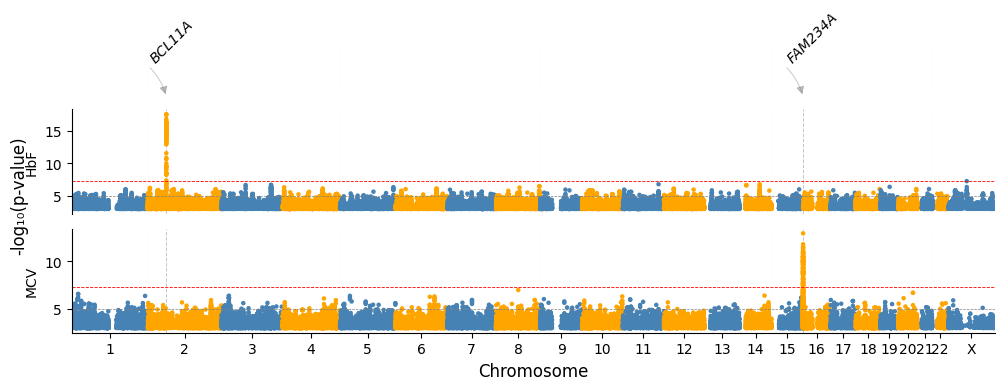

In [19]:
fig, axes = plot_linear(
    sumstats_loaded=sumstats_loaded, 
    track_heights=[0.5,1,1], 
    hits_table=hits_table, 
    plot_title="test_pycmplot_python_api",
    label_col='top_gene', 
    output_format='png',
    dpi=300, chr_spacing=0.0,
    point_size=5,
    signif_lines=signif_lines,
    logp=True, colors=['steelblue','orange'], 
    figsize=(10, 4), 
    trim_pval=0.001
)

### Highlighting significant loci and annotating by SNP

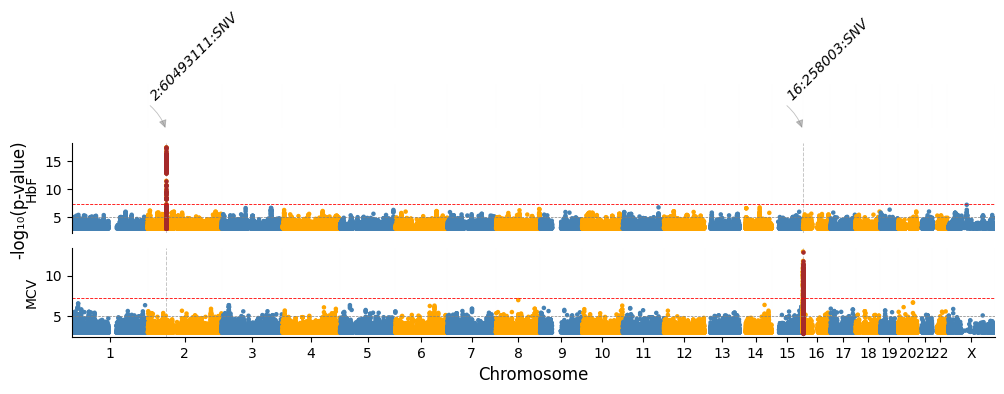

In [20]:
fig, axes = plot_linear(
    sumstats_loaded=sumstats_loaded, 
    track_heights=[0.5,1,1], 
    hits_table=hits_table, 
    plot_title="test_pycmplot_python_api",
    label_col='SNP', 
    output_format='png',
    dpi=300, chr_spacing=0.0,
    point_size=5,
    signif_lines=signif_lines,
    highlight=True,
    logp=True, colors=['steelblue','orange'], 
    figsize=(10, 4), 
    trim_pval=0.001
)

### Highlighting by a different p-value threshold and changing plot colors and removing track labels

- Notice that a chrX locus is highlighted but not annotated. 

- This is because it did not meat the default significance threshold used in the data preparation function that generated the hits table.

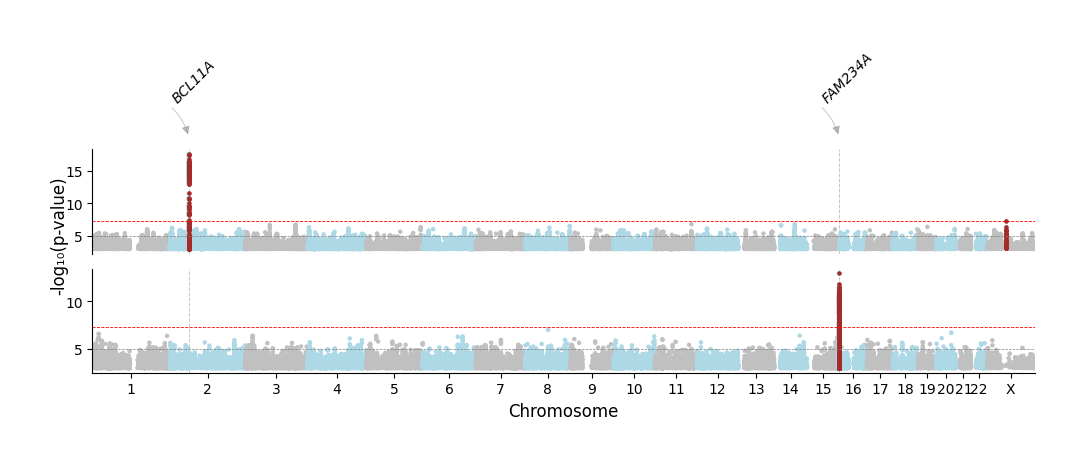

In [6]:
fig, axes = plot_linear(
    sumstats_loaded=sumstats_loaded, 
    track_heights=[0.5,1,1],
    no_track_labels=True,
    hits_table=hits_table, 
    plot_title="test_pycmplot_python_api",
    label_col='nearest_upstream_gene', 
    output_format='png',
    dpi=300, chr_spacing=0.0,
    point_size=5,
    signif_lines=signif_lines,
    highlight=True,
    highlight_thresh=1e-7,
    logp=True, colors=['silver','lightblue'], 
    figsize=(10, 4), 
    trim_pval=0.001
)

## Generating circular plots

- Here, we specify gene annotation by the ```annotate``` argument.
- It takes either `SNP` or `GENE`. When `GENE` is specified, the `top_gene` column in the hits table will be used.

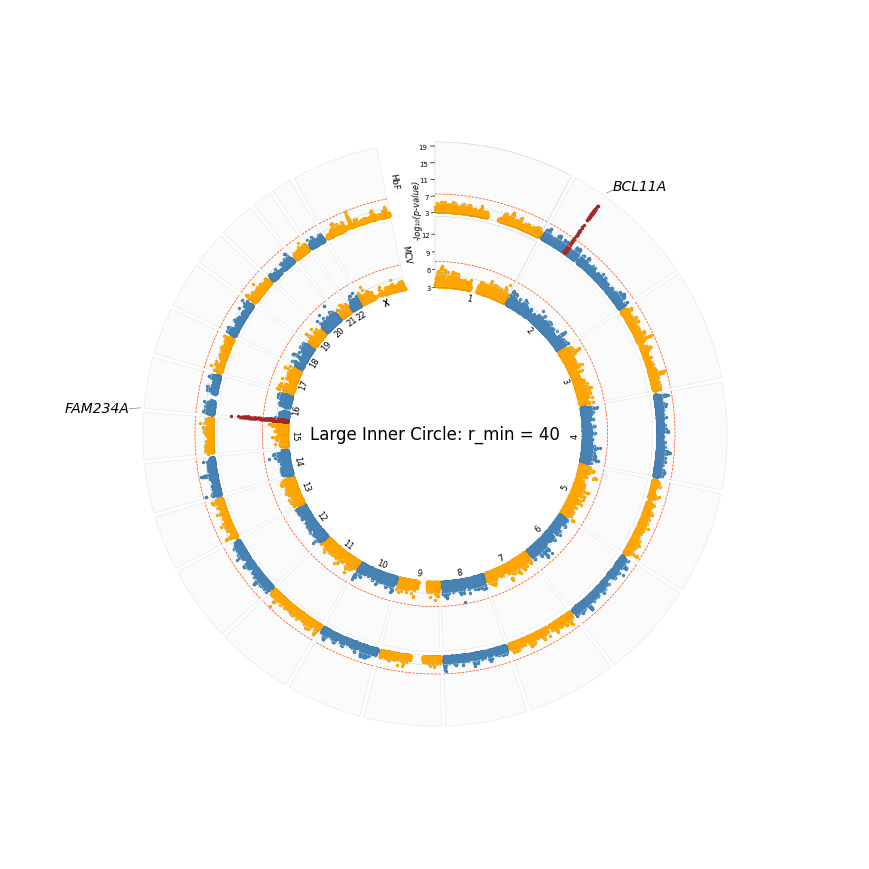

In [10]:
fig = plot_circular(
    sumstats_loaded=sumstats_loaded,
    hits_table=hits_table,
    sector_sizes=merged_sector_sizes,
    annotate="GENE",
    plot_title="Large Inner Circle: r_min = 40",
    #label_col='top_gene', 
    output_format='png',
    annotation_size=10,
    dpi=300, 
    highlight=True,
    pad=1,
    r_min=40,
    r_max=100,
    signif_lines=signif_lines,
    logp=True, colors=['steelblue','orange'], 
    #figsize=(10, 4), 
)

### Controling the inner circle size

- The inner circle size is controled by the `r_min` (minimum radius) argument. It indicates the proportion of the figure the inner circle occupies.

- When dealing with a few sumstats, it should be appropriate to use a relatively high value so the tracks (Manhattan plots) a well represented.

- With many more sumstats, `r_min` should be lower. For instance, I have noticed that `r_min = 20` works well for >= 4 sumstats. 20 is thus the default when `r_min` is not set.

- The total size of the circle is also determined by `r_max` (maximum radius). It is recommended to always use the default of 100.

- For instance, we will use `r_min = 10` below so you see that the plot looks messy with 2 sumstats.

- We can control the size of the plot title using `plot_title_size`. However, anything fitted within that tiny space would not be visible.

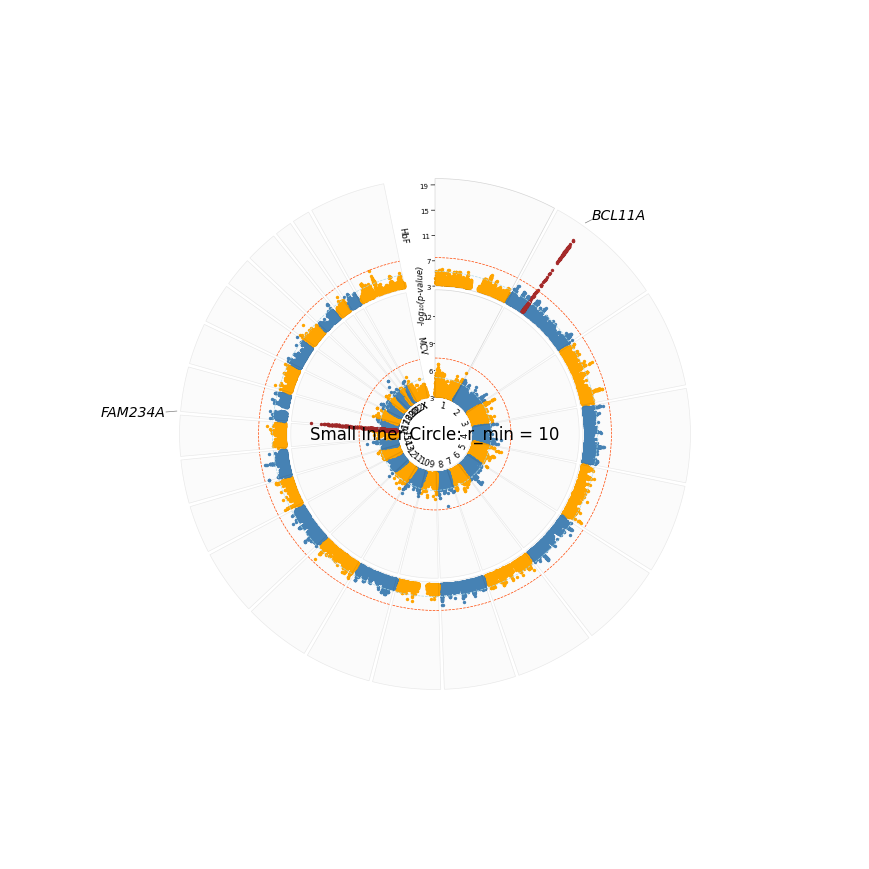

In [12]:
fig = plot_circular(
    sumstats_loaded=sumstats_loaded,
    hits_table=hits_table,
    sector_sizes=merged_sector_sizes,
    annotate="GENE",
    plot_title="Small Inner Circle: r_min = 10",
    #label_col='top_gene', 
    output_format='png',
    annotation_size=10,
    dpi=300, 
    highlight=True,
    pad=1,
    r_min=10,
    r_max=100,
    signif_lines=signif_lines,
    logp=True, colors=['steelblue','orange'], 
    #figsize=(10, 4), 
)

#### We can make it look better by placing chrom labels outside, and excluding plot title and track labels

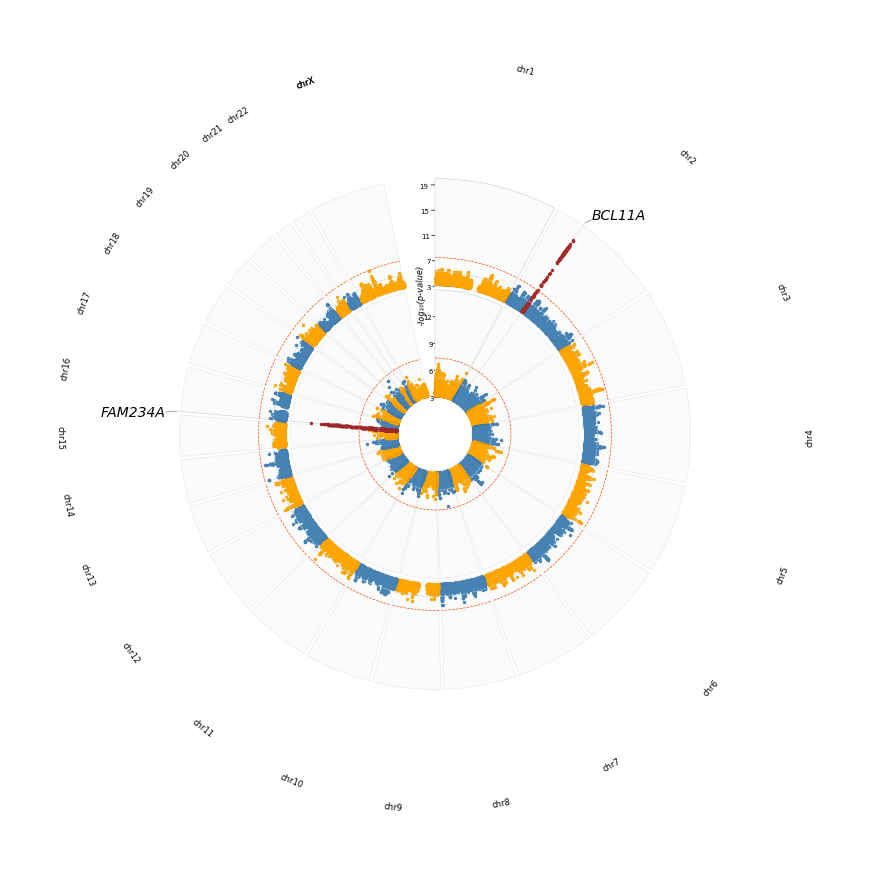

In [8]:
fig = plot_circular(
    sumstats_loaded=sumstats_loaded,
    hits_table=hits_table,
    sector_sizes=merged_sector_sizes,
    annotate="GENE",
    #plot_title="test_pycmplot_python_api",
    chrom_label_side='outside',
    output_format='png',
    annotation_size=10,
    dpi=300, 
    highlight=True,
    highlight_line=True,
    no_track_labels=True,
    pad=1,
    r_min=10,
    r_max=100,
    signif_lines=signif_lines,
    logp=True, colors=['steelblue','orange'], 
    #figsize=(10, 4), 
)

#### SNP Annotation, highlight threshold and color change

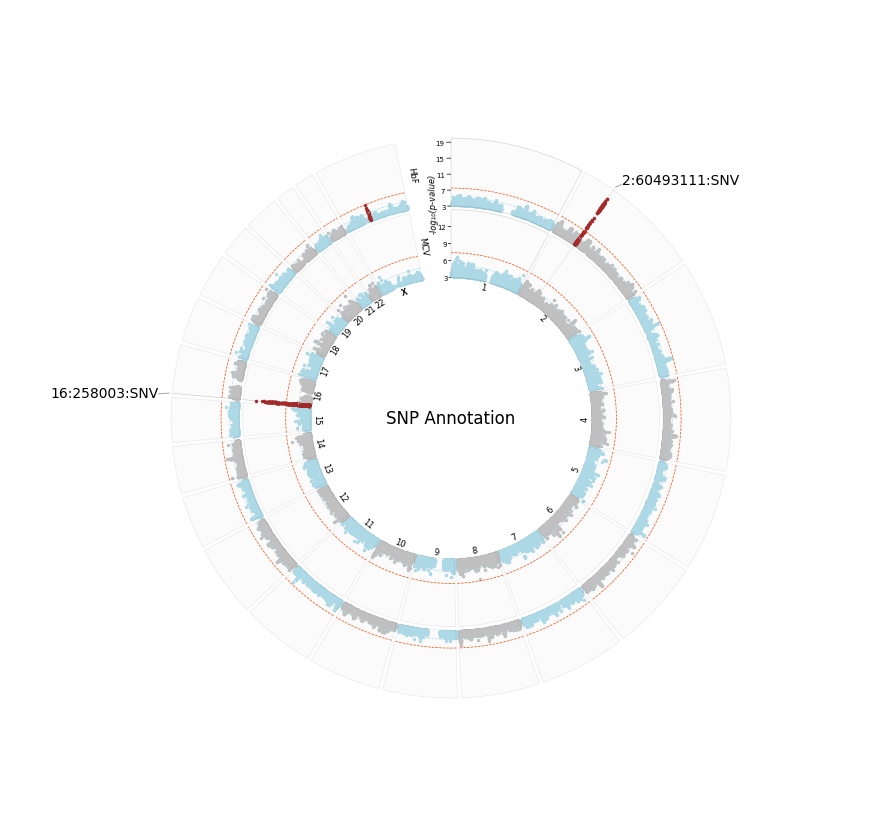

In [17]:
fig = plot_circular(
    sumstats_loaded=sumstats_loaded,
    hits_table=hits_table,
    sector_sizes=merged_sector_sizes,
    annotate="SNP",
    plot_title="SNP Annotation",
    #label_col='top_gene', 
    output_format='png',
    annotation_size=10,
    dpi=300, 
    highlight=True,
    highlight_line=True, 
    highlight_thresh=1e-7,
    pad=1,
    r_min=40,
    r_max=100,
    signif_lines=signif_lines,
    logp=True, colors=['silver','lightblue'], 
    #figsize=(10, 4), 
)

## Ensuring all highlighted loci are also annotated

- We set the same `signif_threshold` and `highlight_thresh` values.

- Remember you can give these outputs any name: `merged_sector_sizes`, `sumstats_loaded`, `hits_table`, `signif_lines`

In [4]:
(merged_sector_sizes, sumstats_loaded, hits_table, signif_lines) = get_sumstats_and_merged_sector_list(
    sum_stats=sumstats_list,
    labels=labels_list, 
    file_info=sumstat_info_dict, 
    logp=True, 
    table_out="test_pycmplot_python_api", 
    trim_pval=0.001,
    signif_threshold=1e-7
)

hits_table

,CHR,POS,SNP,P,BUILD,logP,LABEL,OLD_POS,OLD_BUILD,genic,...,promoter_upstream_flag,gene_density,top_gene,biotype,priority_score,distance,promoter_flag,distance_score,biotype_weight,promoter_bonus
1,2,60493111,2:60493111:SNV,3.039700e-18,hg38,17.517169,HbF,60493111,hg38,True,...,False,46.0,BCL11A,protein_coding,4.0,0,False,1.0,1.0,0.0
0,16,258003,16:258003:SNV,1.094200e-13,hg38,12.960903,MCV,258003,hg38,True,...,False,150.0,FAM234A,protein_coding,4.0,0,False,1.0,1.0,0.0
2,X,63094194,23:62313664:SNV,5.633700e-08,hg38,7.249206,HbF,62313664,hg19,False,...,False,NaN,SPIN4-ARHGEF9,intergenic,NaN,253034-540773,None,NaN,NaN,NaN


#### See that we now have three loci in the hits table

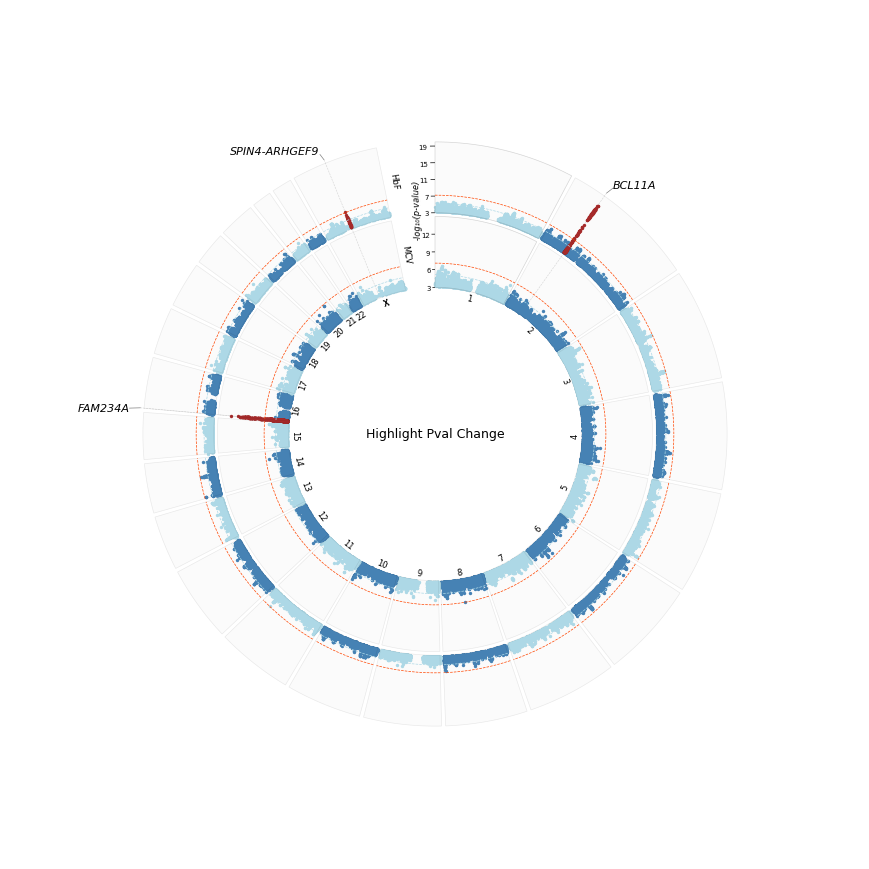

In [29]:
fig1 = plot_circular(
    sumstats_loaded=sumstats_loaded,
    hits_table=hits_table,
    sector_sizes=merged_sector_sizes,
    annotate="GENE",
    plot_title="Highlight Pval Change",
    plot_title_size=9,
    #label_col='top_gene', 
    output_format='png',
    annotation_size=8,
    dpi=300, 
    highlight=True,
    highlight_thresh=1e-7,
    highlight_line=True,
    pad=1,
    r_min=40,
    r_max=100,
    signif_lines=signif_lines,
    logp=True, colors=['steelblue','lightblue'], 
    #figsize=(10, 4), 
)

### Explicitly speficying directory where output files should be stored

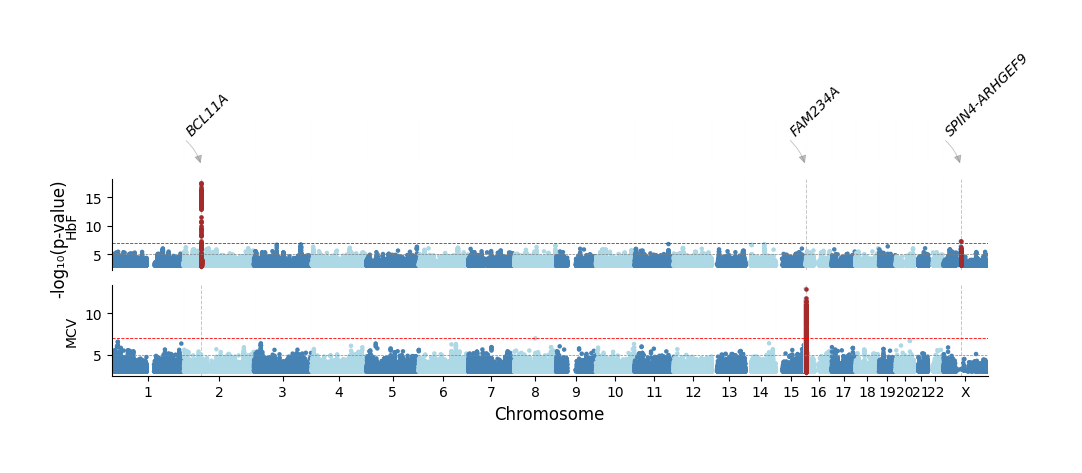

In [51]:
fig2, axes = plot_linear(
    sumstats_loaded=sumstats_loaded, 
    track_heights=[0.5,1,1], 
    hits_table=hits_table, 
    plot_title="test_pycmplot_python_api",
    output_dir='/home/kesohku1/projects/gwas/', # <--- output directory
    label_col='top_gene', 
    output_format='png',
    dpi=300, chr_spacing=0.0,
    point_size=5,
    highlight=True,
    highlight_thresh=1e-7,
    signif_lines=signif_lines,
    logp=True, colors=['steelblue','lightblue'], 
    figsize=(10, 4), # (with, height)
    trim_pval=0.001
)

# Final Notes

- The `prep_pycmplot_input_info` function saves the hits table as a TAB delimited file (.tsv) with the plot title provided combined with the labels and type of plot (lm or cm).

- If plot title is not provided, the function generates a random string for the file name and plot name.

- All files are saved in the user provided output directory using `output_dir`. If not provided, the current directory `'.'` is used.